This notebook provides examples to go along with the [textbook](https://underactuated.csail.mit.edu/simple_legs.html).  I recommend having both windows open, side-by-side!


In [25]:
import copy

import mpld3
import numpy as np
from IPython.display import display
from matplotlib import pyplot as plt
from pydrake.all import (
    BasicVector,
    ConstantVectorSource,
    DiagramBuilder,
    LeafSystem,
    LogVectorOutput,
    PortDataType,
    PublishEvent,
    PyPlotVisualizer,
    Simulator,
    StartMeshcat,
    UnrestrictedUpdateEvent,
    WitnessFunctionDirection,
    namedview,
)

from underactuated import running_as_notebook
from underactuated.pyplot_utils import AdvanceToAndVisualize

if running_as_notebook:
    mpld3.enable_notebook()

In [26]:
# Start the visualizer (run this cell only once, each instance consumes a port)
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at https://e28c3fa3-7878-493c-9565-8eea757f5026.deepnoteproject.com/7001/


# The Spring-Loaded Inverted Pendulum (SLIP)

In [27]:
SLIPState = namedview(
    "SLIPState", ["x", "z", "r", "theta", "xdot", "zdot", "rdot", "thetadot"]
)


class SpringLoadedInvertedPendulum(LeafSystem):
    def __init__(self):
        LeafSystem.__init__(self)

        self.DeclareVectorInputPort("touchdown_angle", 1)
        state_index = self.DeclareContinuousState(BasicVector(np.zeros(8)), 4, 4, 0)
        self.DeclareStateOutputPort("state", state_index)

        # Parameters from Geyer05, p.23
        self.mass = 80.0  # kg
        self.r0 = 1.0  # m
        self.gravity = 9.81  # m/s^2
        # Define spring constant in terms of the dimensionless number.
        # Definition in section 2.4.3, values in figure 2.4.
        # Note: Geyer05 says 10.8 (which doesn't work? -- I get no fixed pts).
        dimensionless_spring_constant = 10.7
        self.stiffness = (
            dimensionless_spring_constant * self.mass * self.gravity / self.r0
        )

        self.last_apex = None  # placeholder for writing return map result.

        self.touchdown_witness = self.MakeWitnessFunction(
            "touchdown",
            WitnessFunctionDirection.kPositiveThenNonPositive,
            self.foot_height,
            UnrestrictedUpdateEvent(self.touchdown),
        )
        self.takeoff_witness = self.MakeWitnessFunction(
            "takeoff",
            WitnessFunctionDirection.kPositiveThenNonPositive,
            self.leg_compression,
            UnrestrictedUpdateEvent(self.takeoff),
        )
        self.apex_witness = self.MakeWitnessFunction(
            "apex",
            WitnessFunctionDirection.kPositiveThenNonPositive,
            self.apex,
            PublishEvent(self.publish_apex),
        )

    def foot_height(self, context):
        s = SLIPState(context.get_continuous_state_vector().CopyToVector())
        return s.z - self.r0 * np.cos(s.theta)

    def touchdown(self, context, event, state):
        s = SLIPState(context.get_mutable_continuous_state_vector().CopyToVector())

        # print("touchdown")

        # Update rdot and thetadot to match xdot and ydot, using
        # x = -r*sin(theta), z = r*cos(theta)
        #  => xdot = -rdot*s - r*c*thetadot, zdot = rdot*c - r*s*thetadot
        #  => xdot*c + zdot*s = -r*thetadot
        # r^2 = x^2 + z^2
        #  => 2r*rdot = 2x*xdot + 2z*zdot
        #  => rdot = -xdot*sin(theta) + zdot*cos(theta)
        # (matches Geyer05 Eq. 2.24 up to the symbol changes)
        s.r = self.r0
        s.rdot = -s.xdot * np.sin(s.theta) + s.zdot * np.cos(s.theta)
        s.thetadot = -(s.xdot * np.cos(s.theta) + s.zdot * np.sin(s.theta)) / self.r0
        state.get_mutable_continuous_state().get_mutable_vector().SetFromVector(s[:])

    def leg_compression(self, context):
        s = SLIPState(context.get_continuous_state_vector().CopyToVector())
        return self.r0 - s.r

    def takeoff(self, context, event, state):
        s = SLIPState(context.get_mutable_continuous_state_vector().CopyToVector())

        # print("takeoff")

        # Setup flight state (these lines aren't strictly required, since we
        # choose to also integrate x and z in stance below).
        s.z = self.r0 * np.cos(s.theta)
        s.xdot = -s.rdot * np.sin(s.theta) - self.r0 * s.thetadot * np.cos(s.theta)
        s.zdot = s.rdot * np.cos(s.theta) - self.r0 * s.thetadot * np.sin(s.theta)

        # Update theta to commanded leg angle.
        s.theta = self.EvalVectorInput(context, 0).GetAtIndex(0)
        s.thetadot = 0
        s.r = self.r0
        s.rdot = 0

        state.get_mutable_continuous_state().get_mutable_vector().SetFromVector(s[:])

    def apex(self, context):
        return context.get_continuous_state_vector().GetAtIndex(5)  # zdot

    def publish_apex(self, context, event):
        # TODO(russt): provide an option to terminate here instead, pending
        # resolution of #4447.
        # print("apex")
        if self.last_apex is None:
            s = SLIPState(context.get_mutable_continuous_state_vector().CopyToVector())
            self.last_apex = s.z

    def apex_velocity_from_dimensionless_system_energy(self, Etilde, z):
        E = Etilde * self.mass * self.gravity * self.r0
        # E = 0.5*m*v^2 + m*g*z
        xdot = np.sqrt(2.0 / self.mass * (E - self.mass * self.gravity * z))
        return xdot

    def energy_flight(self, context):
        s = SLIPState(context.get_mutable_continuous_state_vector().CopyToVector())
        return (
            0.5 * self.mass * (s.xdot**2 + s.zdot**2) + self.mass * self.gravity * s.z
        )

    def energy_stance(self, context):
        s = SLIPState(context.get_mutable_continuous_state_vector().CopyToVector())
        return (
            0.5 * self.mass * (s.rdot**2 + s.r**2 * s.thetadot**2)
            + self.mass * self.gravity * s.r * np.cos(s.theta)
            + 0.5 * self.stiffness * (self.r0 - s.r) ** 2
        )

    def DoGetWitnessFunctions(self, context):
        return [
            self.touchdown_witness,
            self.takeoff_witness,
            self.apex_witness,
        ]

    def DoCalcTimeDerivatives(self, context, derivatives):
        s = SLIPState(context.get_continuous_state_vector().CopyToVector())
        sdot = SLIPState(np.zeros(8))
        sdot[0:4] = s[4:8]

        if self.foot_height(context) < 0:
            # then we're in "stance"
            sdot.rdot = (
                self.stiffness / self.mass * (self.r0 - s.r)
                + s.r * s.thetadot**2
                - self.gravity * np.cos(s.theta)
            )
            sdot.thetadot = (
                self.gravity / s.r * np.sin(s.theta) - 2 * s.rdot * s.thetadot / s.r
            )

            # Integrate x and z also, just for the sake of visualization (all
            # the integrated values except x will be overwritten in the
            # take-off reset).
            # x = -r*sin(theta), y = r*cos(theta) =>
            sdot.xdot = (
                -sdot.rdot * np.sin(s.theta)
                - 2 * s.rdot * s.thetadot * np.cos(s.theta)
                + s.r * s.thetadot**2 * np.sin(s.theta)
                - s.r * sdot.thetadot * np.cos(s.theta)
            )
            sdot.zdot = (
                sdot.rdot * np.cos(s.theta)
                - 2 * s.rdot * s.thetadot * np.sin(s.theta)
                - s.r * sdot.thetadot * np.sin(s.theta)
                - s.r * s.thetadot**2 * np.cos(s.theta)
            )

        else:
            sdot.xdot = 0
            sdot.zdot = -self.gravity
            sdot.rdot = 0
            sdot.thetadot = 0

        derivatives.get_mutable_vector().SetFromVector(sdot[:])


class SLIPVisualizer(PyPlotVisualizer):
    def __init__(self, ax=None, show=True):
        PyPlotVisualizer.__init__(self, ax=ax, show=show, figsize=(12, 4))
        self.DeclareInputPort("slip_state", PortDataType.kVectorValued, 8)
        self.ax.set_aspect("equal")
        self.ax.set_xlim(0, 2)
        self.ax.set_ylim(-0.1, 1.5)

        # Draw the ground.
        self.ax.plot([-50, 50], [0, 0], "k")

        a = np.linspace(0, 2 * np.pi, 50)
        radius = 0.1
        self.hip_fill = self.ax.fill(
            radius * np.sin(a),
            radius * np.cos(a),
            zorder=1,
            edgecolor="k",
            facecolor=[0.6, 0.6, 0.6],
        )
        self.hip = copy.copy(self.hip_fill[0].get_path().vertices)

        self.leg_line = [self.ax.plot([0, 0], [0, -1], "k")[0]]
        self.leg_data = [self.leg_line[0].get_xydata().T]
        for i in range(1, 13):
            self.leg_line.append(
                self.ax.plot(
                    0.1
                    * np.array(
                        [
                            np.sin((i - 1) * np.pi / 2.0),
                            np.sin(i * np.pi / 2.0),
                        ]
                    ),
                    -0.2 - 0.7 / 13 * np.array([i - 1, i]),
                    "k",
                )[0]
            )
            self.leg_data.append(self.leg_line[i].get_xydata().T)

    def draw(self, context):
        state = SLIPState(self.EvalVectorInput(context, 0).CopyToVector())

        self.hip_fill[0].get_path().vertices[:, 0] = state.x + self.hip[:, 0]
        self.hip_fill[0].get_path().vertices[:, 1] = state.z + self.hip[:, 1]

        R = np.array(
            [
                [np.cos(state.theta), -np.sin(state.theta)],
                [np.sin(state.theta), np.cos(state.theta)],
            ]
        )
        for i in range(len(self.leg_line)):
            self.leg_line[i].set_xdata(
                state.x + state.r * R[0, :].dot(self.leg_data[i])
            )
            self.leg_line[i].set_ydata(
                state.z + state.r * R[1, :].dot(self.leg_data[i])
            )

        self.ax.set_title("t = {:.1f}".format(context.get_time()))

In [28]:
def slip_demo():
    builder = DiagramBuilder()
    plant = builder.AddSystem(SpringLoadedInvertedPendulum())

    # Parameters from Geyer05, Figure 2.4
    # Note: Geyer uses angle of attack = 90 - touchdown_angle
    touchdown_angle = np.deg2rad(30)
    Etilde = 1.61

    s = SLIPState(np.zeros(8))
    s.z = 0.9
    s.theta = touchdown_angle
    s.r = 1
    s.xdot = plant.apex_velocity_from_dimensionless_system_energy(Etilde, s.z)

    visualizer = builder.AddSystem(SLIPVisualizer(show=False))
    builder.Connect(plant.get_output_port(0), visualizer.get_input_port(0))

    LogVectorOutput(plant.get_output_port(0), builder)

    command = builder.AddSystem(ConstantVectorSource([touchdown_angle]))
    builder.Connect(command.get_output_port(0), plant.get_input_port(0))

    diagram = builder.Build()
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    context.SetAccuracy(1e-10)

    context.get_mutable_continuous_state_vector().SetFromVector(s[:])

    AdvanceToAndVisualize(simulator, visualizer, 2.0)


slip_demo()

simulating...  WARNING:matplotlib.axes._base:Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
done.
generating animation...


## Apex-to-apex map

In [29]:
def slip_map():
    plant = SpringLoadedInvertedPendulum()

    # Parameters from Geyer05, Figure 2.4
    # Note: Geyer uses angle of attack = 90 - touchdown_angle
    touchdown_angle = np.deg2rad(30)
    Etilde = 1.61

    s = SLIPState(np.zeros(8))
    s.theta = touchdown_angle
    s.r = 1

    simulator = Simulator(plant)
    context = simulator.get_mutable_context()
    plant.get_input_port(0).FixValue(context, [touchdown_angle])
    context.SetAccuracy(1e-5)

    zs = np.linspace(np.cos(touchdown_angle) + 0.001, 0.95, 25)
    zns = 0 * zs
    for i in range(len(zs)):
        s.z = zs[i]
        s.xdot = plant.apex_velocity_from_dimensionless_system_energy(Etilde, s.z)
        context.SetTime(0.0)
        context.get_mutable_continuous_state_vector().SetFromVector(s[:])
        simulator.Initialize()
        # Note: With this duration, I sometimes get an extra "touchdown" after the
        # apex, which results in apex-touchdown; touchdown-takeoff-apex on the
        # console.  It's not a double reset, the consecutive touchdowns are two
        # different sims.
        simulator.AdvanceTo(0.6)
        zns[i] = plant.last_apex
        plant.last_apex = None

    fig, ax = plt.subplots()
    ax.plot(zs, zns)
    ax.plot(zs, zs)
    ax.axis("equal")
    ax.set_xlim([zs[0], zs[-1]])
    ax.set_ylim([zs[0], zs[-1]])
    ax.set_xlabel("apex height z[n]")
    ax.set_ylabel("apex height z[n+1]")

    display(mpld3.display())


slip_map()

/usr/local/lib/python3.10/dist-packages/mpld3/mplexporter/utils.py:300: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates._SwitchableDateConverter)
/usr/local/lib/python3.10/dist-packages/mpld3/mplexporter/utils.py:303: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.DateConverter)
/usr/local/lib/python3.10/dist-packages/mpld3/mplexporter/utils.py:306: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.ConciseDateConverter)
/usr/local/lib/python3.10/dist-packages/mpld3/mplexporter/utils.py:300: M

In [30]:
import numpy as np
from scipy.optimize import root_scalar
from pydrake.all import DiagramBuilder, Simulator, ConstantVectorSource

def compute_next_apex(z_n, touchdown_angle_deg=30.0, k=10.7, Etilde=1.61):
    """
    映射函数：计算给定当前 Apex 高度下，系统下一个 Apex 的高度。
    """
    builder = DiagramBuilder()
    plant = builder.AddSystem(SpringLoadedInvertedPendulum())
    
    # 修改刚度
    plant.stiffness = k * plant.mass * plant.gravity / plant.r0
    
    touchdown_angle = np.deg2rad(touchdown_angle_deg)
    
    s = SLIPState(np.zeros(8))
    s.z = z_n
    s.theta = touchdown_angle
    s.r = plant.r0
    
    try:
        s.xdot = plant.apex_velocity_from_dimensionless_system_energy(Etilde, s.z)
        if np.isnan(s.xdot): return np.nan
    except: return np.nan
        
    s.zdot = 0.0
    
    command = builder.AddSystem(ConstantVectorSource([touchdown_angle]))
    builder.Connect(command.get_output_port(0), plant.get_input_port(0))
    
    diagram = builder.Build()
    simulator = Simulator(diagram)
    
    # 模拟流程
    context = simulator.get_mutable_context()
    context.SetAccuracy(1e-10)
    context.get_mutable_continuous_state_vector().SetFromVector(s[:])
    
    simulator.AdvanceTo(0.05) # 避开起始瞬间
    plant.last_apex = None    # 清空记录
    simulator.AdvanceTo(2.0)
    
    return plant.last_apex if plant.last_apex is not None else np.nan

def find_fixed_points_for_parameters(touchdown_angle_deg=30.0, k=10.7, Etilde=1.61, z_range=(0.8, 1.1), steps=50):
    """
    寻根函数：寻找 h(n+1) - h(n) = 0 的不动点。
    """
    def map_diff(z):
        next_z = compute_next_apex(z, touchdown_angle_deg, k, Etilde)
        return next_z - z if not np.isnan(next_z) else np.nan

    z_vals = np.linspace(z_range[0], z_range[1], steps)
    diff_vals = [map_diff(z) for z in z_vals]
    
    roots = []
    for i in range(len(z_vals) - 1):
        if not np.isnan(diff_vals[i]) and not np.isnan(diff_vals[i+1]):
            if diff_vals[i] * diff_vals[i+1] <= 0:
                sol = root_scalar(map_diff, bracket=[z_vals[i], z_vals[i+1]], method='brentq')
                if sol.converged: roots.append(sol.root)
                    
    return roots

In [9]:
find_fixed_points_for_parameters(touchdown_angle_deg=30.0, k=10.7, Etilde=1.61, z_range=(0.8, 1.1), steps=50)

[0.8768132025802357, 0.916844328313806]

In [32]:
def compute_floquet_multiplier(z_star, touchdown_angle_deg=30.0, k=10.7, Etilde=1.61, delta=1e-4):
    """
    计算 Poincare 映射在不动点 z_star 处的导数 (Floquet Multiplier)。
    使用中心差分法：f'(z) ≈ (f(z+delta) - f(z-delta)) / (2 * delta)
    """
    # 计算 z_star + delta 和 z_star - delta 的映射结果
    f_plus = compute_next_apex(z_star + delta, touchdown_angle_deg, k, Etilde)
    f_minus = compute_next_apex(z_star - delta, touchdown_angle_deg, k, Etilde)
    
    if np.isnan(f_plus) or np.isnan(f_minus):
        return np.nan
        
    # 计算斜率
    multiplier = (f_plus - f_minus) / (2 * delta)
    return multiplier

# --- 验证刚才找到的那两个不动点的稳定性 ---
roots = [0.8768132025802357, 0.916844328313806]
for root in roots:
    fm = compute_floquet_multiplier(root, k=10.7)
    is_stable = abs(fm) < 1
    print(f"不动点 z* = {root:.4f} 的 Floquet Multiplier: {fm:.4f} | 稳定性: {'稳定' if is_stable else '不稳定'}")

不动点 z* = 0.8768 的 Floquet Multiplier: 0.4878 | 稳定性: 稳定
不动点 z* = 0.9168 的 Floquet Multiplier: 1.3463 | 稳定性: 不稳定


In [31]:
#降低能量寻找不动点
find_fixed_points_for_parameters(touchdown_angle_deg=30.0, k=10.7, Etilde=1.0, z_range=(0.8, 1.1), steps=50)

[0.9021862773565786]

In [33]:
roots_= [0.9021862773565786]
for root in roots_:
    fm = compute_floquet_multiplier(root, k=10.7)
    is_stable = abs(fm) < 1
    print(f"不动点 z* = {root:.4f} 的 Floquet Multiplier: {fm:.4f} | 稳定性: {'稳定' if is_stable else '不稳定'}")
for root in roots_:
    fm = compute_floquet_multiplier(root, k=10.7)
    is_stable = abs(fm) < 1
    print(f"不动点 z* = {root:.4f} 的 Floquet Multiplier: {fm:.4f} | 稳定性: {'稳定' if is_stable else '不稳定'}")

不动点 z* = 0.9022 的 Floquet Multiplier: 1.1259 | 稳定性: 不稳定
不动点 z* = 0.9022 的 Floquet Multiplier: 1.1259 | 稳定性: 不稳定


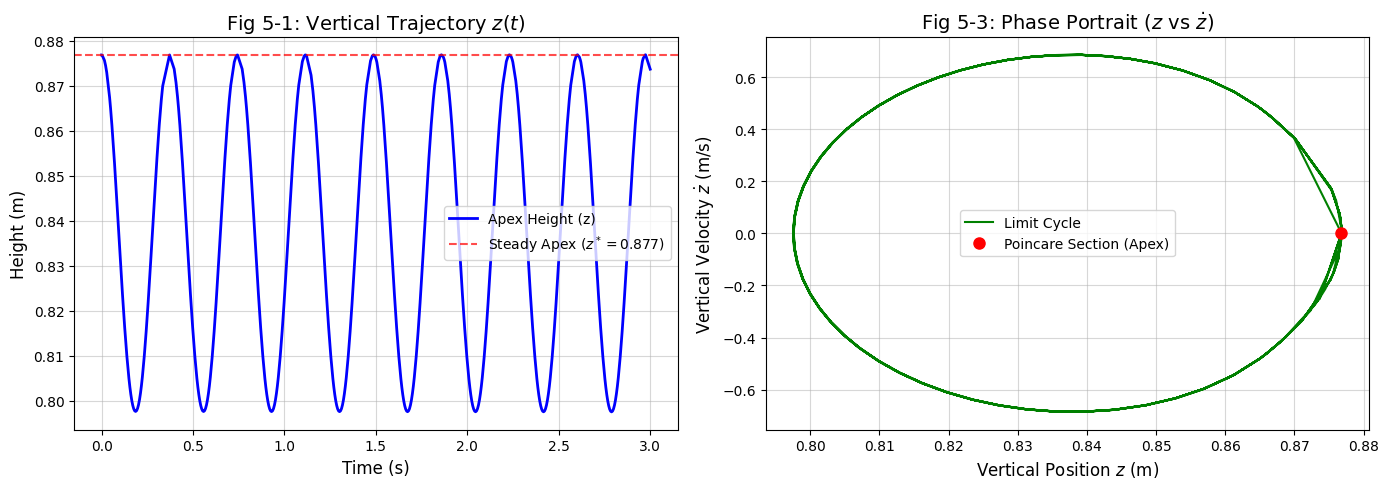

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pydrake.all import DiagramBuilder, Simulator, ConstantVectorSource, LogVectorOutput

def plot_missing_report_figures_fixed():
    # 采用我们找到的最优稳态参数
    z_stable = 0.8768
    touch_deg = 30.0
    k_val = 10.7
    Etilde = 1.61
    
    # 建立系统
    builder = DiagramBuilder()
    plant = builder.AddSystem(SpringLoadedInvertedPendulum())
    plant.stiffness = k_val * plant.mass * plant.gravity / plant.r0
    
    # 记录状态数据，准备画图
    logger = LogVectorOutput(plant.get_output_port(0), builder)
    command = builder.AddSystem(ConstantVectorSource([np.deg2rad(touch_deg)]))
    builder.Connect(command.get_output_port(0), plant.get_input_port(0))
    
    diagram = builder.Build()
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    
    # ================= 【核心修复】 =================
    # 给积分器设置解算精度，解决连续动力学仿真报错问题
    context.SetAccuracy(1e-8)
    # ===============================================
    
    # 赋予完美的不动点初值
    s = SLIPState(np.zeros(8))
    s.z = z_stable
    s.theta = np.deg2rad(touch_deg)
    s.r = plant.r0
    s.xdot = plant.apex_velocity_from_dimensionless_system_energy(Etilde, s.z)
    s.zdot = 0.0
    context.get_mutable_continuous_state_vector().SetFromVector(s[:])
    
    # 跑 3 秒数据，足够展示 3-4 个跳跃周期
    simulator.AdvanceTo(3.0)
    
    # 提取日志数据
    log = logger.FindLog(context)
    time = log.sample_times()
    data = log.data() 
    z = data[1, :]    # 高度
    x = data[3, :]    # 水平位移
    zdot = data[5, :] # 垂直速度
    
    # ================= 绘图开始 =================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 图 5-1: 状态响应曲线 (高度随时间变化)
    ax1.plot(time, z, 'b-', linewidth=2, label='Apex Height (z)')
    ax1.axhline(y=z_stable, color='r', linestyle='--', alpha=0.7, label=f'Steady Apex ($z^*={z_stable:.3f}$)')
    ax1.set_title('Fig 5-1: Vertical Trajectory $z(t)$', fontsize=14)
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_ylabel('Height (m)', fontsize=12)
    ax1.grid(True, alpha=0.5)
    ax1.legend()
    
    # 图 5-3: 极限环相平面图 (Phase Portrait: z vs zdot)
    ax2.plot(z, zdot, 'g-', linewidth=1.5, label='Limit Cycle')
    ax2.plot(z_stable, 0.0, 'ro', markersize=8, label='Poincare Section (Apex)')
    ax2.set_title('Fig 5-3: Phase Portrait ($z$ vs $\dot{z}$)', fontsize=14)
    ax2.set_xlabel('Vertical Position $z$ (m)', fontsize=12)
    ax2.set_ylabel('Vertical Velocity $\dot{z}$ (m/s)', fontsize=12)
    ax2.grid(True, alpha=0.5)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# 一键生成报告图表
plot_missing_report_figures_fixed()

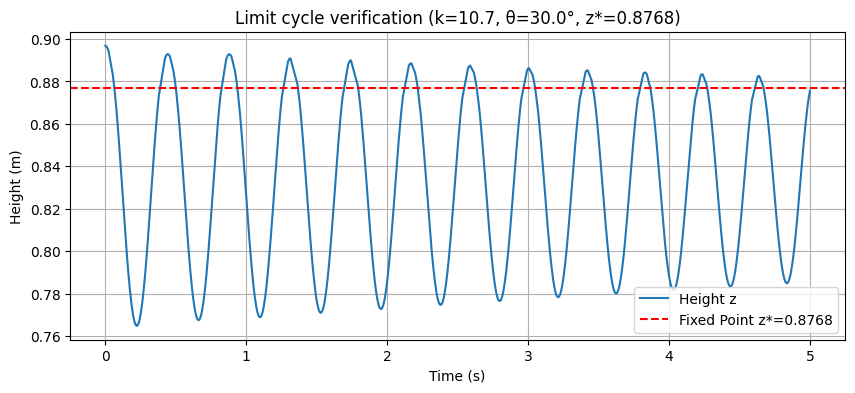

In [11]:
#初步稳定性测试

import matplotlib.pyplot as plt
import numpy as np
from pydrake.all import DiagramBuilder, Simulator, LogVectorOutput

# 稳定参数
z_stable = 0.8768132025802357  # 不动点高度
touch_deg = 30.0               # 触地角
k_val = 10.7                   # 无量纲弹簧常数
Etilde = 1.61                  # 无量纲能量

# 1. 创建 diagram
builder = DiagramBuilder()
plant = builder.AddSystem(SpringLoadedInvertedPendulum())
# 修改刚度
plant.stiffness = k_val * plant.mass * plant.gravity / plant.r0

# 添加状态记录器
logger = LogVectorOutput(plant.get_output_port(0), builder)

# 构建 diagram
diagram = builder.Build()

# 2. 仿真器
sim = Simulator(diagram)
diagram_context = sim.get_mutable_context()
diagram_context.SetAccuracy(1e-6)

# 3. 获取 plant 的子系统上下文，并固定输入
plant_context = diagram.GetMutableSubsystemContext(plant, diagram_context)
plant.get_input_port(0).FixValue(plant_context, [np.deg2rad(touch_deg)])

# 4. 设置初始状态 (稍微给一点点扰动，例如 +0.02，看看它是否会回到 0.8768)
s0 = SLIPState(np.zeros(8))
s0.theta = np.deg2rad(touch_deg)
s0.r = 1.0
s0.z = z_stable + 0.02 
s0.xdot = plant.apex_velocity_from_dimensionless_system_energy(Etilde, z_stable + 0.02)
plant_context.get_mutable_continuous_state_vector().SetFromVector(s0[:])

# 5. 仿真 (设置长一点时间，以便观察收敛过程)
sim.AdvanceTo(5.0)

# 6. 获取日志
log = logger.FindLog(diagram_context)
time = log.sample_times()
states = log.data()

# 7. 绘图
plt.figure(figsize=(10, 4))
plt.plot(time, states[1, :], label='Height z')
# 画一条参考线，标出不动点高度
plt.axhline(y=z_stable, color='r', linestyle='--', label=f'Fixed Point z*={z_stable:.4f}')

plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title(f'Limit cycle verification (k={k_val}, θ={touch_deg}°, z*={z_stable:.4f})')
plt.grid(True)
plt.legend()
plt.savefig('slip_limit_cycle.png')

In [12]:
#仿真动画

class SLIPVisualizerTracking_New(PyPlotVisualizer):
    def __init__(self, ax=None, show=True):
        PyPlotVisualizer.__init__(self, ax=ax, show=show, figsize=(12, 4))
        self.DeclareInputPort("slip_state", PortDataType.kVectorValued, 8)
        self.ax.set_aspect("equal")
        # 初始视场设置
        self.ax.set_xlim(-1, 1)
        self.ax.set_ylim(-0.1, 1.5)

        # 把地面画得足够长，或者动态画，这里设得非常长，保证跑不到尽头
        self.ax.plot([-500, 500], [0, 0], "k")

        a = np.linspace(0, 2 * np.pi, 50)
        radius = 0.1
        self.hip_fill = self.ax.fill(
            radius * np.sin(a),
            radius * np.cos(a),
            zorder=1,
            edgecolor="k",
            facecolor=[0.6, 0.6, 0.6],
        )
        self.hip = copy.copy(self.hip_fill[0].get_path().vertices)

        self.leg_line = [self.ax.plot([0, 0], [0, -1], "k")[0]]
        self.leg_data = [self.leg_line[0].get_xydata().T]
        for i in range(1, 13):
            self.leg_line.append(
                self.ax.plot(
                    0.1
                    * np.array(
                        [
                            np.sin((i - 1) * np.pi / 2.0),
                            np.sin(i * np.pi / 2.0),
                        ]
                    ),
                    -0.2 - 0.7 / 13 * np.array([i - 1, i]),
                    "k",
                )[0]
            )
            self.leg_data.append(self.leg_line[i].get_xydata().T)
        
        for i in range(-50, 50):
            self.ax.axvline(x=i * 2, color='pink', linestyle='--', linewidth=2.0, alpha=0.8, zorder = 0)

    def draw(self, context):
        state = SLIPState(self.EvalVectorInput(context, 0).CopyToVector())

        self.hip_fill[0].get_path().vertices[:, 0] = state.x + self.hip[:, 0]
        self.hip_fill[0].get_path().vertices[:, 1] = state.z + self.hip[:, 1]

        R = np.array(
            [
                [np.cos(state.theta), -np.sin(state.theta)],
                [np.sin(state.theta), np.cos(state.theta)],
            ]
        )
        for i in range(len(self.leg_line)):
            self.leg_line[i].set_xdata(
                state.x + state.r * R[0, :].dot(self.leg_data[i])
            )
            self.leg_line[i].set_ydata(
                state.z + state.r * R[1, :].dot(self.leg_data[i])
            )

        self.ax.set_title("t = {:.1f}".format(context.get_time()))
        
        # ==========================================
        # 核心改动：动态更新 X 轴范围，实现镜头跟随！
        # 让 X 轴的中心始终对准机器人的 state.x
        # ==========================================
        self.ax.set_xlim(state.x - 1.5, state.x + 1.5)

def slip_demo_2d_long():
    builder = DiagramBuilder()
    plant = builder.AddSystem(SpringLoadedInvertedPendulum())
    
    # ==========================================
    # 核心修复：直接修改对象属性，根据无量纲参数计算实际的 stiffness
    # ==========================================
    dimensionless_k = 10.4
    plant.stiffness = dimensionless_k * plant.mass * plant.gravity / plant.r0

    # ==========================================
    # 你提供的不动点参数
    # ==========================================
    touchdown_angle_deg = 30.0
    touchdown_angle = np.deg2rad(touchdown_angle_deg)
    z_fixed = 0.8768
    
    s = SLIPState(np.zeros(8))
    s.z = z_fixed
    s.theta = touchdown_angle
    s.r = 1.0  # 初始腿长
    
    # 设定无量纲能量，通常 Geyer05 中的固定点搜索基于 Etilde = 1.61
    Etilde = 1.61
    s.xdot = plant.apex_velocity_from_dimensionless_system_energy(Etilde, s.z)
    # 如果你有精确的 xdot 也可以直接在这里写死，例如: fs.xdot = 3.5
    # ==========================================

    # 使用带有镜头跟踪的 2D 动画类
    visualizer = builder.AddSystem(SLIPVisualizerTracking_New(show=False))
    builder.Connect(plant.get_output_port(0), visualizer.get_input_port(0))

    LogVectorOutput(plant.get_output_port(0), builder)

    command = builder.AddSystem(ConstantVectorSource([touchdown_angle]))
    builder.Connect(command.get_output_port(0), plant.get_input_port(0))

    diagram = builder.Build()
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    context.SetAccuracy(1e-10)

    # 初始化状态
    context.get_mutable_continuous_state_vector().SetFromVector(s[:])

    print(f"正在以 k={dimensionless_k}, theta={touchdown_angle_deg}度, z={z_fixed} 运行长仿真...")
    AdvanceToAndVisualize(simulator, visualizer, 10.0)

# 执行函数
slip_demo_2d_long()

正在以 k=10.4, theta=30.0度, z=0.8768 运行长仿真...
simulating...  WARNING:matplotlib.axes._base:Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
done.
generating animation...


开始实验 A: 扫描 k (共 60 点)...
进度 1/120 | 当前 k=9.00
进度 2/120 | 当前 k=9.07
进度 3/120 | 当前 k=9.14
进度 4/120 | 当前 k=9.20
进度 5/120 | 当前 k=9.27
进度 6/120 | 当前 k=9.34
进度 7/120 | 当前 k=9.41
进度 8/120 | 当前 k=9.47
进度 9/120 | 当前 k=9.54
进度 10/120 | 当前 k=9.61
进度 11/120 | 当前 k=9.68
进度 12/120 | 当前 k=9.75
进度 13/120 | 当前 k=9.81
进度 14/120 | 当前 k=9.88
进度 15/120 | 当前 k=9.95
进度 16/120 | 当前 k=10.02
进度 17/120 | 当前 k=10.08
进度 18/120 | 当前 k=10.15
进度 19/120 | 当前 k=10.22
进度 20/120 | 当前 k=10.29
进度 21/120 | 当前 k=10.36
进度 22/120 | 当前 k=10.42
进度 23/120 | 当前 k=10.49
进度 24/120 | 当前 k=10.56
进度 25/120 | 当前 k=10.63
进度 26/120 | 当前 k=10.69
进度 27/120 | 当前 k=10.76
进度 28/120 | 当前 k=10.83
进度 29/120 | 当前 k=10.90
进度 30/120 | 当前 k=10.97
进度 31/120 | 当前 k=11.03
进度 32/120 | 当前 k=11.10
进度 33/120 | 当前 k=11.17
进度 34/120 | 当前 k=11.24
进度 35/120 | 当前 k=11.31
进度 36/120 | 当前 k=11.37
进度 37/120 | 当前 k=11.44
进度 38/120 | 当前 k=11.51
进度 39/120 | 当前 k=11.58
进度 40/120 | 当前 k=11.64
进度 41/120 | 当前 k=11.71
进度 42/120 | 当前 k=11.78
进度 43/120 | 当前 k=11.85
进度 44/120 

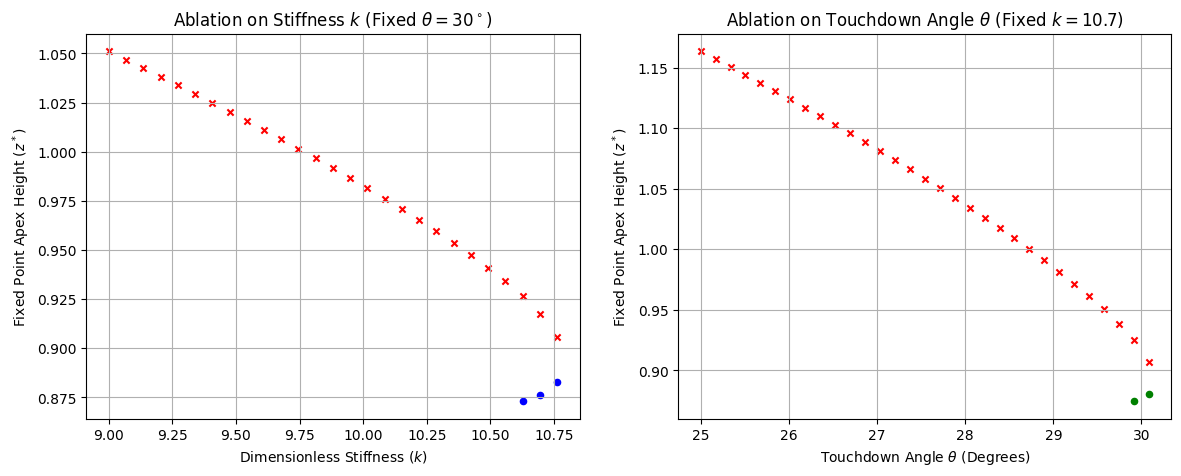

In [35]:
#消融实验（时间久）

import numpy as np
import matplotlib.pyplot as plt

def run_high_res_ablation_study():
    Etilde = 1.61
    
    # 60个采样点
    num_pts = 60
    k_range = np.linspace(9.0, 13.0, num_pts)
    theta_range = np.linspace(25.0, 35.0, num_pts)
    
    # 建立画板，开启实时显示模式
    plt.ion() 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 配置 ax1
    ax1.set_title('Ablation on Stiffness $k$ (Fixed $\\theta=30^\\circ$)')
    ax1.set_xlabel('Dimensionless Stiffness ($k$)')
    ax1.set_ylabel('Fixed Point Apex Height ($z^*$)')
    ax1.grid(True)
    
    # 配置 ax2
    ax2.set_title('Ablation on Touchdown Angle $\\theta$ (Fixed $k=10.7$)')
    ax2.set_xlabel('Touchdown Angle $\\theta$ (Degrees)')
    ax2.set_ylabel('Fixed Point Apex Height ($z^*$)')
    ax2.grid(True)
    
    total = len(k_range) + len(theta_range)
    count = 0
    
    # --- 实验 A：固定 Theta，扫描 k ---
    print(f"开始实验 A: 扫描 k (共 {len(k_range)} 点)...")
    for k in k_range:
        count += 1
        print(f"进度 {count}/{total} | 当前 k={k:.2f}")
        try:
            # 搜索范围和步长保持稳定
            roots = find_fixed_points_for_parameters(touchdown_angle_deg=30.0, k=k, Etilde=Etilde, z_range=(0.7, 1.2), steps=30)
            for r in roots:
                fm = compute_floquet_multiplier(r, touchdown_angle_deg=30.0, k=k, Etilde=Etilde)
                color, marker = ('blue', 'o') if abs(fm) < 1.0 else ('red', 'x')
                ax1.scatter(k, r, color=color, marker=marker, s=20)
            fig.canvas.draw_idle() # 实时刷新图表
        except: continue
        
    # --- 实验 B：固定 k，扫描 Theta ---
    print(f"开始实验 B: 扫描 Theta (共 {len(theta_range)} 点)...")
    for theta in theta_range:
        count += 1
        print(f"进度 {count}/{total} | 当前 Theta={theta:.1f}°")
        try:
            roots = find_fixed_points_for_parameters(touchdown_angle_deg=theta, k=10.7, Etilde=Etilde, z_range=(0.7, 1.2), steps=30)
            for r in roots:
                fm = compute_floquet_multiplier(r, touchdown_angle_deg=theta, k=10.7, Etilde=Etilde)
                color, marker = ('green', 'o') if abs(fm) < 1.0 else ('red', 'x')
                ax2.scatter(theta, r, color=color, marker=marker, s=20)
            fig.canvas.draw_idle() # 实时刷新图表
        except: continue
        
    plt.ioff() # 关闭实时模式
    print("实验完全结束！")
    plt.show()

# 运行
run_high_res_ablation_study()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e28c3fa3-7878-493c-9565-8eea757f5026' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>